In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

f:\Langgraph\myenv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
class StudentInfo(TypedDict):
    name: str
    marks: list
    total_marks: int
    avg_marks: float 
    highest_marks: int


In [ ]:
# In parallel workflow, the "name" key was being updated 3 times
# by different nodes simultaneously, so LangGraph raised an error.

# To avoid this, each parallel node should return only the specific
# key-value pair that it is responsible for updating.

# Each node should update unique keys only.

def calculate_total_marks(state: StudentInfo) -> StudentInfo:
    return {"total_marks": sum(state["marks"])}

def calculate_avg_marks(state: StudentInfo) -> StudentInfo:
    return {"avg_marks": sum(state["marks"]) // len(state["marks"])}
    

def calculate_highest_marks(state: StudentInfo) -> StudentInfo:
    return {"highest_marks": max(state["marks"])}

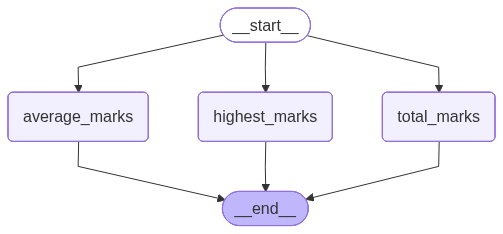

In [10]:
graph = StateGraph(StudentInfo)

graph.add_node("total_marks", calculate_total_marks)
graph.add_node("average_marks", calculate_avg_marks)
graph.add_node("highest_marks", calculate_highest_marks)

graph.add_edge(START, "total_marks")
graph.add_edge(START, "average_marks")
graph.add_edge(START, "highest_marks")

graph.add_edge("total_marks", END)
graph.add_edge("average_marks", END)
graph.add_edge("highest_marks", END)

workflow = graph.compile()
workflow


In [11]:
workflow.invoke({"name":"Aasiya", "marks":[81, 84, 90, 92, 92, 88]})

{'name': 'Aasiya',
 'marks': [81, 84, 90, 92, 92, 88],
 'total_marks': 527,
 'avg_marks': 87,
 'highest_marks': 92}